# Review

In [9]:
import os
import requests
import pandas as pd

# Week 1

## W.1.A File paths where is this notebook?

In [4]:
# Current path
import os
# os.getcwd(): Shows current folder this notebook is in
os.getcwd()

'/Users/cory/Desktop/datascience-publicpolicy-2026/notebooks/week_11'

In [5]:
# This shows the current folder
os.listdir()

['1-review.ipynb']

In [6]:
# This shows the files in the folder three folders above the current folder
os.listdir("../..")[:3]

['requirements.txt', 'uv.lock', 'environment.yml']

### W.1.1 Importing data

In [ ]:
import pandas as pd
df = pd.read_csv("../../data/examples/week_2/world_bank_data.csv")
df.head(2)

,Unnamed: 0,indicator,country,countryiso3code,date,value
0,0,GDP per capita (current US$),Canada,CAN,2023,53431.185706
1,1,GDP per capita (current US$),Canada,CAN,2022,55509.393176


### W.1.2 Data types

In [8]:
my_str = 'Python is cool'
print(my_str)

Python is cool


In [9]:
my_num = 100
type(my_num)

int

In [10]:
indicator_code = 'SP.POP.TOTL'  # Example: Total population
country_list = ['FR', 'DE', 'IT'] # France, Germany, Italy
start_year = '2020'
end_year = '2022'

In [11]:
rename_country_map = {
    "Canada": "Canada",
    "Mexico": "United Mexican States",
    "United States": "United States of America",
    "Germany": "Federal Republic of Germany",
}

### W.1.3 Info, Descriptive etc

In [12]:
df.describe().head(2)

,Unnamed: 0,date,value
count,12.0,12.0,12.000000
mean,5.5,2022.0,44741.011336


In [13]:
df.columns

Index(['Unnamed: 0', 'indicator', 'country', 'countryiso3code', 'date',
       'value'],
      dtype='str')

## W.1.5 Filter renaming 

In [14]:
df['country'].head(2)

0    Canada
1    Canada
Name: country, dtype: str

In [15]:
# Filter and rename
df.query("country == 'Japan'").rename({"value" : "GDP"}, axis=1)

,Unnamed: 0,indicator,country,countryiso3code,date,GDP
3,3,GDP per capita (current US$),Japan,JPN,2023,33766.526825
4,4,GDP per capita (current US$),Japan,JPN,2022,34017.271808
5,5,GDP per capita (current US$),Japan,JPN,2021,40058.537328


In [16]:
df.query("country in ['Japan', 'Mexico']")[['country', 'date']]

,country,date
3,Japan,2023
4,Japan,2022
5,Japan,2021
6,Mexico,2023
7,Mexico,2022
8,Mexico,2021


## W.2 Downloading data

### W.2.1 World Bank

In [16]:
import requests
import io

def download_worldbank(indicator, countries, date_start, date_end):
    """
    A helper function to download data from the World Bank API.
    """
    url_base = 'https://api.worldbank.org/v2/'
    country_codes = ';'.join(countries)
    url = f'{url_base}country/{country_codes}/indicator/{indicator}?date={date_start}:{date_end}&per_page=30000'
    response = requests.get(url)
    
    # Reading the XML response into pandas
    df = pd.read_xml(io.BytesIO(response.content))
    return df

In [18]:
indicator_code = 'SP.POP.TOTL'  # Example: Total population
country_list = ['FR', 'DE', 'IT'] # France, Germany, Italy
start_year = '2020'
end_year = '2022'

df_wb = download_worldbank(
    indicator=indicator_code,
    countries=country_list,
    date_start=start_year,
    date_end=end_year
)
df_wb.head(2)

,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"Population, total",Germany,DEU,2022,83177813,NaN,NaN,0
1,"Population, total",Germany,DEU,2021,83196078,NaN,NaN,0


In [19]:
rename_country_map = {"United States": "United States of America", 
                      "Germany": "Federal Republic of Germany"}
df_wb.country.map(rename_country_map).head(2)

0    Federal Republic of Germany
1    Federal Republic of Germany
Name: country, dtype: str

### W.2.2 IMF

In [23]:
def fetch_and_process_data(url, key):
    # Fetch data from the API
    response = requests.get(f"{url}{key}", headers={"Accept": "text/csv"})
    response.raise_for_status()
    # Parse the CSV response into a dataframe indexed by date
    df = pd.read_csv(io.StringIO(response.text))
    df["TIME_PERIOD"] = pd.to_datetime(
        df["TIME_PERIOD"].astype(str).str.replace("-M", "-"), errors="coerce"
    )
    df = (
        df.dropna(subset=["TIME_PERIOD"])
        .set_index("TIME_PERIOD")[["OBS_VALUE"]]
        .astype(float)
    )
    return df.rename(columns={"OBS_VALUE": key})


# Example usage
url = "https://api.imf.org/external/sdmx/3.0/data/dataflow/IMF.STA/CPI/~/"
key = "GBR.CPI._T.IX.M"
df = fetch_and_process_data(url, key)
df.head(2)

,GBR.CPI._T.IX.M
TIME_PERIOD,
1955-01-01,4.859513
1955-02-01,4.859513


### W.2.3 Global Macro database

In [24]:
url = 'https://github.com/KMueller-Lab/Global-Macro-Database/raw/refs/heads/main/data/final/chainlinked_infl.dta'
df_macro = pd.read_stata(url)
df_macro.head(2)

,ISO3,year,ADB_infl,AHSTAT_infl,AMF_infl,BCEAO_infl,BIS_infl,BORDO_infl,CEPAC_infl,EUS_infl,...,OECD_KEI_infl,WB_CC_infl,WDI_infl,WDI_ARC_infl,CS1_infl,CS2_infl,infl,chainlinking_ratio,source,source_change
0,ZWE,2029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5.131044,1.0,IMF_WEO,NaN
1,ZWE,2028.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5.108963,1.0,IMF_WEO,NaN


### W.2.4 Merge

In [25]:
df_wb_final = df_wb.rename(columns = {"countryiso3code": "ISO3", "value" : "population", "date":"year"})[['ISO3', 'year','population']]
df_wb_final.head(2)

,ISO3,year,population
0,DEU,2022,83177813
1,DEU,2021,83196078


In [26]:
df_merge = pd.merge(  # Merge the two DataFrames
    df_wb_final,
    df_macro.astype({"year":int}),  # Ensure 'year' is of int type in df_macro
    on = ["ISO3", 'year']  # Merge on ISO3 and year columns
)[['ISO3', 'year','population', 'BIS_infl']].dropna()  # Select specific columns and drop rows with NaN values
df_merge['year'] = pd.to_datetime(df_merge['year'], format='%Y')  # Convert 'year' to datetime format
df_merge = df_merge.set_index(['ISO3', 'year']).sort_index()
df_merge.head(2)  

population  BIS_infl
ISO3 year                            
DEU  2020-01-01    83160871  0.536193
     2021-01-01    83196078  3.066667

### W.2.5 Reshape data

In [27]:
df_long = df_merge.stack().reset_index()
df_long.head(2)

,ISO3,year,level_2,0
0,DEU,2020-01-01,population,8.316087e+07
1,DEU,2020-01-01,BIS_infl,5.361930e-01


In [28]:
df_wide = df_long.pivot(
    index = 'year',
    columns = ['ISO3', 'level_2'],
    values = 0
)
df_wide.head(2)

ISO3               DEU                   FRA                   ITA          
level_2     population  BIS_infl  population  BIS_infl  population  BIS_infl
year                                                                        
2020-01-01  83160871.0  0.536193  67601110.0  0.476499  59438851.0 -0.137708
2021-01-01  83196078.0  3.066667  67842811.0  1.642331  59133173.0  1.873783

In [29]:
df_panel = df_long.pivot(
    index = ['ISO3', 'year'],
    columns =  'level_2',
    values = 0
)
df_panel.head(2)

level_2          BIS_infl  population
ISO3 year                            
DEU  2020-01-01  0.536193  83160871.0
     2021-01-01  3.066667  83196078.0

## W.3 Functions

### W.3.A Function basics

In [30]:
def add_func(a, b, c):
    final = a + b + c
    return final
add_func(5, 3, 2)

10

### W.3.1 Function

In [8]:
def download_macro_data(url):
    print(f"Fetching macroeconomic data from: {url}")  # Print the URL from which data is being fetched
    df = pd.read_stata(url)  # Read the Stata data file from the provided URL
    df = df.dropna(subset=['year'])  # Drop rows where the 'year' column has NaN values
    df['year'] = pd.to_datetime(df['year'].astype(int), format='%Y', errors='coerce')  # Convert 'year' to datetime, handling any conversion errors
    return df  # Return the cleaned DataFrame

df_inflation = download_macro_data('https://github.com/KMueller-Lab/Global-Macro-Database/raw/refs/heads/main/data/final/chainlinked_infl.dta')  # Fetch and process inflation data
df_inflation.head(2) 

Fetching macroeconomic data from: https://github.com/KMueller-Lab/Global-Macro-Database/raw/refs/heads/main/data/final/chainlinked_infl.dta


NameError: name 'pd' is not defined

### W.3.2 Python Program (OOP): Tool with many functions

In [32]:
class SimpleOperationPerformer:
    def perform_string_print(self, input_string):
        print("Running perform_string_print...")  # Print a message indicating the function is running
        result = input_string  # Assign the input string to the result variable
        print(f"The result of string_print function: {result}")  # Print the result of the function
        return result  # Return the result

    def perform_addition(self, num1, num2, num3):
        print("Running perform_addition...")  # Print a message indicating the function is running
        final = num1 + num2 + num3  # Perform the addition of the three numbers
        print(f"The result of add_func function: {final}")  # Print the result of the addition
        return final  # Return the result

ot = SimpleOperationPerformer()  # Create an instance of the SimpleOperationPerformer class
ot.perform_string_print('Hello from individual call!')  # Call the perform_string_print method with a string
ot.perform_addition(10, 20, 30)  # Call the perform_addition method with three numbers

Running perform_string_print...
The result of string_print function: Hello from individual call!
Running perform_addition...
The result of add_func function: 60


60

### W.3.3 Tool to download and merge data

In [33]:
import pandas as pd
import requests
import io
import os

class Data:
    def __init__(self, intermediate_folder="intermediate/", raw_folder="raw/"):  # Create the DataProcessor with folder paths
        self.intermediate_folder = intermediate_folder  # Set the folder for intermediate data
        self.raw_folder = raw_folder  # Set the folder for raw data
        self.df_oecd = None  # Create OECD data frame
        self.df_oecd_nz = None  # Create New Zealand OECD data frame

    def download_oecd(self, oecd_url):  # Download OECD data from a URL
        print("Running download_oecd...")
        response = requests.get(oecd_url)  # Send GET request to URL
        response.raise_for_status()  # Raise an error for bad status codes
        data = io.StringIO(response.text)  # Convert response text to string IO
        self.df_oecd = pd.read_csv(data)  # Read CSV data from string IO
        return self.df_oecd

    def filter_rename_oecd_nz(self):  # Filter and rename New Zealand OECD data
        print("Running filter_rename_oecd_nz...")
        cols_oecd = ['REF_AREA', 'TIME_PERIOD', 'OBS_VALUE', 'MEASURE', 'UNIT_MEASURE']  # Define columns to keep
        self.df_oecd_nz = self.df_oecd[cols_oecd].query("REF_AREA == 'NZL' & MEASURE=='ULCE' & UNIT_MEASURE == 'PA'").copy()  # Filter and select columns
        self.df_oecd_nz.rename({"REF_AREA": 'country', "TIME_PERIOD": 'date', 'OBS_VALUE': 'ULCE'}, axis=1, inplace=True)  # Rename columns
        self.df_oecd_nz.drop(["MEASURE", "UNIT_MEASURE"], axis=1, inplace=True)  # Drop unnecessary columns
        return self.df_oecd_nz

    def convert_datetime_oecd_nz(self):  # Convert date column in OECD data to datetime
        print("Running convert_datetime_oecd_nz...")
        self.df_oecd_nz['date'] = pd.PeriodIndex(self.df_oecd_nz['date'], freq='Q').to_timestamp().date  # Convert quarterly date to datetime
        return self.df_oecd_nz

    def set_index_oecd_nz(self):  # Set index for OECD data
        print("Running set_index_oecd_nz...")
        self.df_oecd_nz.set_index(['country', 'date'], inplace=True)  # Set index to country and date
        print("OECD data index set to country and date.")
        return self.df_oecd_nz



In [34]:
# Let's create our DataProcessor tool.
processor = Data()
oecd_data_url = "https://sdmx.oecd.org/public/rest/data/OECD.SDD.TPS,DSD_PDB@DF_PDB_ULC_Q,1.0/.Q.......?startPeriod=1990-Q4&format=csv"
# Download OECD data
oecd_df = processor.download_oecd(oecd_data_url)
# 4. Filter and rename OECD data for New Zealand
oecd_nz_df = processor.filter_rename_oecd_nz()
# 6. Convert datetime in OECD data
oecd_nz_df_dt = processor.convert_datetime_oecd_nz()
# 8. Set index for OECD data
oecd_nz_df_indexed = processor.set_index_oecd_nz()

Running download_oecd...
Running filter_rename_oecd_nz...
Running convert_datetime_oecd_nz...
Running set_index_oecd_nz...
OECD data index set to country and date.


### W.3.4 Importing previous tool from a python file instead

In [2]:
import os
#Our python files are always in the src folder
os.listdir("../../src/data/")

['data_merge.py',
 '__pycache__',
 'data_example.py',
 'data_manipulate.py',
 'data_import.py']

In [1]:
# import sys
# sys.path.append("../../src/data/")
# # Import functions individual
# from function_basic import string_print
# string_print('yes')

In [3]:
import sys
sys.path.append("../../src/data/")

from data_example import DataProcessor
macro_data_url = 'https://github.com/KMueller-Lab/Global-Macro-Database/raw/refs/heads/main/data/final/chainlinked_infl.dta'
oecd_data_url = "https://sdmx.oecd.org/public/rest/data/OECD.SDD.TPS,DSD_PDB@DF_PDB_ULC_Q,1.0/.Q.......?startPeriod=1990-Q4&format=csv"
processor = DataProcessor(macro_data_url, oecd_data_url)
processor.run_pipeline()

INFO: Fetching macroeconomic data from: https://github.com/KMueller-Lab/Global-Macro-Database/raw/refs/heads/main/data/final/chainlinked_infl.dta
INFO: Macroeconomic data loaded successfully with shape: (20405, 33)
INFO: Fetching OECD data from: https://sdmx.oecd.org/public/rest/data/OECD.SDD.TPS,DSD_PDB@DF_PDB_ULC_Q,1.0/.Q.......?startPeriod=1990-Q4&format=csv
INFO: OECD data loaded successfully with shape: (54287, 16)
INFO: Filtered macroeconomic data for NZL with shape: (108, 4)
INFO: Filtered OECD data for NZL with shape: (142, 5)
INFO: Renamed columns in macroeconomic data for NZL.
INFO: Renamed and dropped columns in OECD data for NZL.
INFO: Converted 'date' column in OECD data for NZL to datetime.date.
INFO: Converted 'date' column in macroeconomic data for NZL to datetime.date.
INFO: Set index for macroeconomic data for NZL.
INFO: Set index for OECD data for NZL.
INFO: Merged DataFrames with shape: (33, 3)
INFO: Exported merged DataFrame to data/intermediate/merged_data_nz.csv


## W.4 Visualization

### W.4.1 Groupby and visualize

In [10]:
# Descriptive stats
df_unemp_raw = download_macro_data('https://github.com/KMueller-Lab/Global-Macro-Database/raw/refs/heads/main/data/final/chainlinked_unemp.dta')
df_unemp_descriptive_bycountry = df_unemp_raw.groupby('ISO3')['unemp'].describe()
df_unemp_descriptive_bycountry.head(2)

Fetching macroeconomic data from: https://github.com/KMueller-Lab/Global-Macro-Database/raw/refs/heads/main/data/final/chainlinked_unemp.dta


,count,mean,std,min,25%,50%,75%,max
ISO3,,,,,,,,
ABW,39.0,7.088641,1.902090,3.250,6.05350,6.90000,8.70000,11.4
AFG,13.0,8.300230,7.950102,1.692,3.37019,3.37046,8.22908,23.9


Text(0.5, 0, 'Unemployment %')

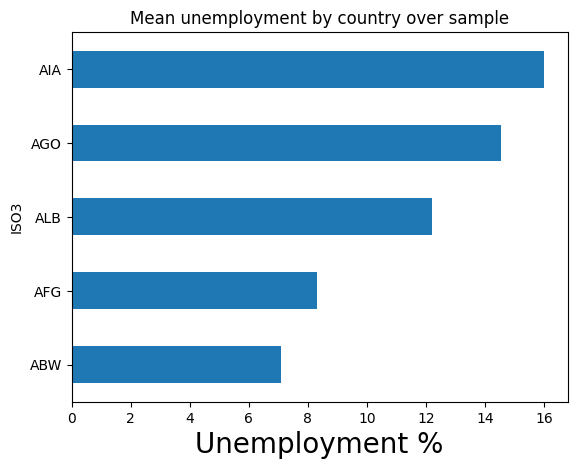

In [11]:
import matplotlib.pyplot as plt
df_unemp_descriptive_bycountry['mean'].head(5).sort_values().plot(kind = 'barh')
plt.title("Mean unemployment by country over sample")
plt.xlabel("Unemployment %", size = 20)

### W.4.2 Seaborn line plots

In [17]:
df_wb_long = download_worldbank(  # Download data from the World Bank
    indicator = 'NY.GDP.PCAP.CD',  # Indicator: GDP per capita (current US$)
    countries = ['US', 'CA', 'MX', 'JP'],  # Countries: United States, Canada, Mexico, Japan
    date_start = '2020',  # Start date of the data range
    date_end = '2023'  # End date of the data range
    ).pivot(  # Pivot the DataFrame to a more usable format
    index = ['countryiso3code', 'date'],  # Set the index to country code and date
    columns = ['indicator'],  # Use the indicator as the column
    values = 'value'  # Use the value column for the data
)
df_wb_long.head(2)  # Display the first 2 rows of the DataFrame

indicator             GDP per capita (current US$)
countryiso3code date                              
CAN             2020                  43537.898120
                2021                  52886.640781

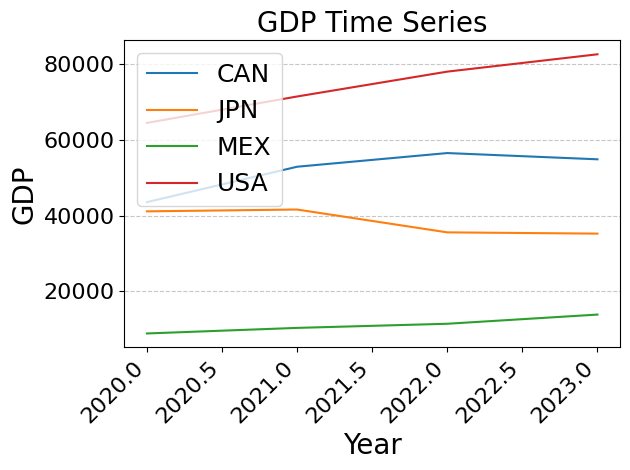

<Figure size 640x480 with 0 Axes>

In [18]:
import seaborn as sns
sns.lineplot(
    data = df_wb_long,      # Dataframe with long format data
    x = 'date',                   # Column for x-axis (dates)
    y = 'GDP per capita (current US$)',         # Column for y-axis (GDP values)
    hue = 'countryiso3code'               # Column for color differentiation (countries)
)
plt.ylabel("GDP", size = 20)      # Y-axis label with font size 20
plt.xlabel("Year", size = 20)     # X-axis label with font size 20
plt.title("GDP Time Series", size = 20)  # Plot title with font size 20

# Additional customizations
plt.xticks(rotation=45, ha='right')  # Rotate x-axis tick labels for readability
plt.yticks(size=14)                  # Set y-axis tick label font size to 14
plt.tick_params(axis='both', labelsize=16)  # Uniform tick label font size for both axes
plt.legend(fontsize=18, loc='upper left')  # Customize legend font size and location
plt.grid(True, axis='y', linestyle='--', alpha=0.7)  # Add a dashed grid for y-axis
plt.tight_layout()                   # Ensure labels fit within the figure area

# Display and Save the plot
plt.show()                           # Display the plot
plt.savefig('gdp_time_series.png',   # Save plot as PNG
            dpi=120,                 # Set resolution (dots per inch)
            bbox_inches='tight',     # Remove excess whitespace
            transparent=False)       # Background transparency (False = opaque)

### W.4.3 Plotting with pipeline python file

In [21]:
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

class PipelineWBDescriptive:
    def __init__(self, indicator, countries, date_start=None, date_end=None):
        self.indicator = indicator
        self.countries = countries
        self.date_start = date_start
        self.date_end = date_end
        self.url_base = 'http://api.worldbank.org/v2/'
        self.df = None
        self.df_pivot = None
        self.df_final = None        

    def download(self, save_data=False):
        country_codes = ';'.join(self.countries)
        url = f'country/{country_codes}/indicator/{self.indicator}?per_page=30000'
        if self.date_start and self.date_end:
            url += f'&date={self.date_start}:{self.date_end}'
        url = self.url_base + url
        response = requests.get(url)
        self.df = pd.read_xml(io.BytesIO(response.content))
        self.df['series'] = self.indicator
        self.df['date'] = pd.to_datetime(self.df['date'], format="%Y")
        if save_data:
            print(f"data save here: data/raw_{self.indicator}.csv')")
            #self.df.to_csv(f'data/raw_{self.indicator}.csv')
        return self.df

    def pivot(self):
        self.df_pivot = self.df.pivot(index=['countryiso3code', 'date'], columns=['series'], values='value').reset_index()
        return self.df_pivot

    def rename_convert(self, save_data=False):
        self.df_final = self.df_pivot.rename({'countryiso3code': 'country', 'date': 'date'}, axis=1)
        self.df_final['date'] = pd.to_datetime(self.df_final['date'], format='%Y')
        if save_data:
            print(f"data save here: cleaned_{self.indicator}.csv")
            self.df_final.to_csv(f'data/cleaned_{self.indicator}.csv')
        return self.df_final
        
    def plot_descriptive(self, title='Descriptive Statistics'):
        desc_stats = self.df_final.groupby("country")[self.indicator].describe().drop(['count'], axis = 'columns').transpose().plot(kind = 'barh')
        desc_stats.plot(kind='barh', figsize=(12, 8), title=title)
        plt.xlabel("Value", size=16)
        plt.ylabel("Country", size=16)
        plt.legend(fontsize=14, loc='best')
        plt.title(title)
        plt.tight_layout()
        plt.show()

# Example Usage
analyze = PipelineWBDescriptive(
    indicator='MS.MIL.XPND.GD.ZS',
    countries=['US', 'CA', 'MX', 'JP'],
    date_start='2020',
    date_end='2023'
)

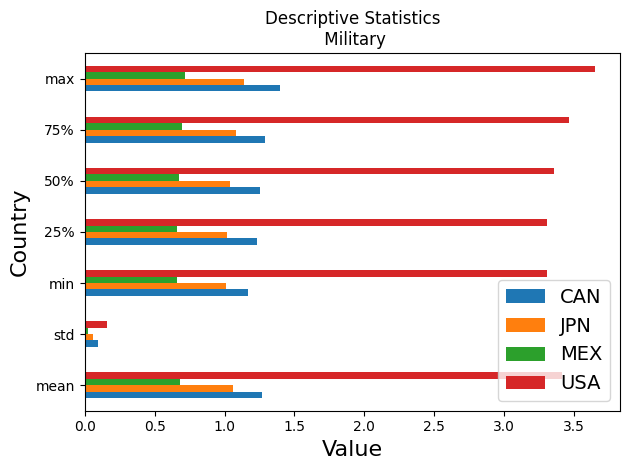

In [23]:
df = analyze.download(save_data = False)
df = analyze.pivot()
df = analyze.rename_convert(save_data = False)
analyze.plot_descriptive(title = "Descriptive Statistics\n Military")

## W.5 Advanced

### W.5.2 Transforming Data

In [28]:
import requests
def download_worldbank(indicator, countries, date_start, date_end):
    url_base = 'http://api.worldbank.org/v2/'  # Base URL for the World Bank API
    country_codes = ';'.join(countries)  # Combine country codes into a string
    url = url_base + f'country/{country_codes}/indicator/{indicator}?date={date_start}:{date_end}&per_page=30000' #create the url with start and end date.
    url = url_base + f'country/{country_codes}/indicator/{indicator}?per_page=30000' # This line overrides the previous one. It will ignore start/end date.
    response = requests.get(url)  # Download data from the URL
    df = pd.read_xml(io.BytesIO(response.content))
    df['series'] = indicator
    df['date'] = pd.to_datetime(df['date'], format="%Y")
    return df.pivot(index=['countryiso3code', 'date'], columns=['series'], values='value')

df_all = []  # Initialize an empty list to store dataframes
data_sets = ['NY.GDP.PCAP.CD', 'SP.POP.TOTL', 'NE.EXP.GNFS.ZS']  # List of World Bank indicators
for indicator in data_sets:  # FOR LOOP through each indicator
    df = download_worldbank(  # Download data for the current indicator
        indicator=indicator,  # Specify the indicator which is cycle through in the FOR LOOP
        countries=['US', 'CA', 'MX', 'JP'],  # Specify the countries
        date_start='2018',  # Start date for the data
        date_end='2023'  # End date for the data
    )
    df_all.append(df)  # Append the downloaded dataframe to the list
    print(indicator)  # Print the current indicator for tracking
df_wb = pd.concat(df_all, axis=1)  # Concatenate all dataframes along the columns
df_wb.head(2)  # Display the first 2 rows of the concatenated dataframe

NY.GDP.PCAP.CD
SP.POP.TOTL
NE.EXP.GNFS.ZS


series                      NY.GDP.PCAP.CD  SP.POP.TOTL  NE.EXP.GNFS.ZS
countryiso3code date                                                   
CAN             1960-01-01     2264.948497     17909356             NaN
                1961-01-01     2246.083566     18271000       17.582919

In [29]:
df_wb_raw = df_wb[['NY.GDP.PCAP.CD','SP.POP.TOTL']].dropna().rename(columns = {'NY.GDP.PCAP.CD':'gdp', 'SP.POP.TOTL':'pop'})
df_wb_raw.index = df_wb_raw.index.rename(['country', 'date'])

def generate_features(df):
    df_out = df.copy()
    df_group = df_out.groupby('country')

    df_diff = df_group.diff(1).add_suffix(f'_chraw1')
    df_out = pd.concat([df_out, df_diff], axis=1)

    df_pct_change = df_group.pct_change(1).add_suffix(f'_chpct1')
    df_out = pd.concat([df_out, df_pct_change], axis=1)

    return df_out 
df_features_simple = generate_features(
    df = df_wb_raw
)
df_features_simple.head(2)

series                      gdp       pop  gdp_chraw1  pop_chraw1  gdp_chpct1  \
country date                                                                    
CAN     1960-01-01  2264.948497  17909356         NaN         NaN         NaN   
        1961-01-01  2246.083566  18271000   -18.86493    361644.0   -0.008329   

series              pop_chpct1  
country date                    
CAN     1960-01-01         NaN  
        1961-01-01    0.020193

### W.5.3 Dashboards

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gradio as gr

df_emissions = pd.read_csv('../../data/hw/ghg.csv')
countries =  ['Indonesia', 'India', 'Ireland']

def plot_emissions(country_list):
    fig, ax = plt.subplots()
    sns.lineplot(df_emissions.query("Country in @country_list"), x='year', y='emissions', hue='Country',ax=ax)
    ax.set_xlabel("Year")
    ax.set_ylabel("Emissions")
    ax.set_title("Emissions Over Time by Country")
    return fig

iface = gr.Interface(
    fn=plot_emissions,
    inputs=gr.CheckboxGroup(choices=countries , label="Select Countries"),
    outputs=gr.Plot(label="Emissions Plot"),
    title="Interactive Emissions Plot",
    description="Select countries to visualize their emissions over time."
)

iface.launch()

INFO: HTTP Request: GET http://127.0.0.1:7860/gradio_api/startup-events "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD http://127.0.0.1:7860/ "HTTP/1.1 200 OK"


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


INFO: HTTP Request: HEAD https://huggingface.co/api/telemetry/https%3A/api.gradio.app/gradio-initiated-analytics "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/api/telemetry/https%3A/api.gradio.app/gradio-launched-telemetry "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK"


## W.6 Regression

### W.6.1 Regression

In [35]:
import statsmodels.api as sm
import pandas as pd

def ols(df, y_data, y_feat, x_data, x_feat):
    y_col = f"{y_data}_{y_feat}" if y_feat else y_data
    x_col = f"{x_data}_{x_feat}" if x_feat else x_data

    data = df[[x_col, y_col]].dropna()
    y = data[y_col]
    X = data[x_col]
    X = sm.add_constant(X)  # Add a constant (intercept) to the independent variable
    model = sm.OLS(y, X)
    results = model.fit()
    return results

r = ols(
    df=df_features_simple,
    y_data='gdp',
    y_feat='chraw1',
    x_data='pop',
    x_feat='chpct1'
)
r.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             gdp_chraw1   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     3.167
Date:                Wed, 01 Jul 2026   Prob (F-statistic):             0.0763
Time:                        06:49:57   Log-Likelihood:                -2340.1
No. Observations:                 260   AIC:                             4684.
Df Residuals:                     258   BIC:                             4691.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1047.9421    217.060      4.828      0.000     620.506    1475.378
pop_chpct1 -2.708e+04   1.52e+04     -1.780      0.076    -5.7e+04    2884.385
==============================================================================
Omnibus:                       48.580   Durbin-Watson:                   1.429
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              341.971
Skew:                          -0.471   Prob(JB):                     5.52e-75
Kurtosis:                       8.539   Cond. No.                         125.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### W.6.2 Interpretting Regression
- Shown in Week 8 notebook

In [36]:
import statsmodels.api as sm
import pandas as pd

def regression_interp(data, y_col, x_col, y_type, x_type, y_name=None, x_name=None, graph=False):
    # Prepare data for regression
    y_series, x_series = data[y_col], data[x_col]
    
    # Add constant to the independent variable(s)
    x_with_const = sm.add_constant(x_series, prepend=True)
    
    # Fit the OLS model
    model = sm.OLS(y_series, x_with_const).fit()
    
    # Get coefficient
    coefficient_scalar = model.params[x_col]
    
    print(f"\n--- Regression Interpretation: {y_name} vs. {x_name} ---")
    print(f"Model: {y_type.capitalize()}-{x_type.capitalize()}")
    print(f"Coefficient: {coefficient_scalar:.3f}")
    
    # Interpretation based on variable types
    if y_type == 'log' and x_type == 'log':  # Log-Log (Elasticity)
        print(f"A 1% increase in {x_name} is associated with a {coefficient_scalar:.3f}% change in {y_name}.")
        
    elif y_type == 'level' and x_type == 'log':  # Level-Log (Semi-elasticity)
        change_in_y_units = coefficient_scalar / 100
        print(f"A 1% increase in {x_name} is associated with a {change_in_y_units:.3f} unit change in {y_name}.")
        
    elif y_type == 'log' and x_type == 'level':  # Log-Level (Semi-elasticity)
        percentage_change_in_y = coefficient_scalar * 100
        print(f"A 1 unit increase in {x_name} is associated with a {percentage_change_in_y:.3f}% change in {y_name}.")
        
    elif y_type == 'level' and x_type == 'level':  # Level-Level (Linear)
        print(f"A 1 unit increase in {x_name} is associated with a {coefficient_scalar:.3f} unit change in {y_name}.")
        
    elif y_type == 'level_pctchange' and x_type == 'level_pctchange':  # Percent change - Percent change
        print(f"A 1 percentage point increase in {x_name} is associated with a {coefficient_scalar:.3f} percentage point change in {y_name}.")
        
    # Handle mixed cases with percent changes
    elif y_type == 'level_pctchange' and x_type == 'level':
        print(f"A 1 unit increase in {x_name} is associated with a {coefficient_scalar:.3f} percentage point change in {y_name}.")
        
    elif y_type == 'level' and x_type == 'level_pctchange':
        print(f"A 1 percentage point increase in {x_name} is associated with a {coefficient_scalar:.3f} unit change in {y_name}.")
        
    elif y_type == 'log' and x_type == 'level_pctchange':
        percentage_change_in_y = coefficient_scalar * 100
        print(f"A 1 percentage point increase in {x_name} is associated with a {percentage_change_in_y:.3f}% change in {y_name}.")
        
    elif y_type == 'level_pctchange' and x_type == 'log':
        change_in_y_pctpts = coefficient_scalar / 100
        print(f"A 1% increase in {x_name} is associated with a {change_in_y_pctpts:.3f} percentage point change in {y_name}.")
        
    
    # Additional model statistics
    print(f"R-squared: {model.rsquared:.2f}" + (f" (Good model fit: Model explains variation in GDP)" if model.rsquared > 0.5 else f" (Bad model fit: Model DOESNT explain variation in GDP)"))
    print(f"P-value: {model.pvalues[x_col]:.3f}" + (f" (Significant)" if model.pvalues[x_col] < 0.05 else f" (Not significant)"))

In [ ]:
data_folder = '../../data/examples/week_10'
import numpy as np
df_reg = pd.read_csv(f"{data_folder}/democracy_gdp.csv")[['country', 'year','NGDPDPC', 'v2x_freexp']].dropna()
df_reg.head(2)
# Log
df_reg['NGDPDPC_log'] = df_reg['NGDPDPC'].apply(np.log)
# pct_change
df_reg['NGDPDPC_chpct1'] = df_reg.groupby('country')['NGDPDPC'].pct_change(1).multiply(100)
# Scale freedom of expresion variable by 100 so it is 0-100 scale
df_reg['v2x_freexp'] = df_reg['v2x_freexp'].multiply(100)
# log
df_reg['v2x_freexp_log'] = df_reg['v2x_freexp'].apply(np.log)
# pct_change
df_reg['v2x_freexp_chpct1'] = df_reg.groupby('country')['v2x_freexp'].pct_change(100)
#
df_reg = df_reg.dropna()
df_reg.head(2)


,country,year,NGDPDPC,v2x_freexp,NGDPDPC_log,NGDPDPC_chpct1,v2x_freexp_log,v2x_freexp_chpct1
625,KOR,1991,7872.91,80.0,8.971183,0.0,4.382027,0.0
626,KOR,1991,7872.91,80.0,8.971183,0.0,4.382027,0.0


In [41]:
regression_interp(data=df_reg,
    y_col='NGDPDPC',
    y_type='level',
    y_name="GDP per capita",
    x_col='v2x_freexp',
    x_type='level',
    x_name="VDEM Freedom of Expression"
)


--- Regression Interpretation: GDP per capita vs. VDEM Freedom of Expression ---
Model: Level-Level
Coefficient: 68.941
A 1 unit increase in VDEM Freedom of Expression is associated with a 68.941 unit change in GDP per capita.
R-squared: 0.00 (Bad model fit: Model DOESNT explain variation in GDP)
P-value: 0.000 (Significant)


### W.6.3 Analysis pipeline
- This is a python file made up of other python files

In [1]:
import sys
sys.path.append("../..")
from src.pipeline.run_pipeline import RunPipeline
analysis_runner = RunPipeline()
analysis_runner.run()

Step 1: Download
Processing indicator: BX.KLT.DINV.WD.GD.ZS
Processing indicator: MS.MIL.XPND.GD.ZS
Processing indicator: NY.GDP.MKTP.CD
Processing indicator: NE.EXP.GNFS.ZS
Processing indicator: NE.IMP.GNFS.ZS
series country       date  BX.KLT.DINV.WD.GD.ZS  MS.MIL.XPND.GD.ZS  \
0          CAN 2010-01-01              1.837250           1.194338   
1          CAN 2011-01-01              2.137822           1.193292   

series  NY.GDP.MKTP.CD  NE.EXP.GNFS.ZS  NE.IMP.GNFS.ZS  
0         1.617349e+12       29.167277       31.040628  
1         1.793336e+12       30.678236       31.820185  

Step 2: Transform
Saved features here: data/features/wb_feat.csv

Step 3: Visualization
Saved plot to: reports/viz/timeseries.png
Saved plot to: reports/viz/histogram.png
                               OLS Regression Results                              
Dep. Variable:     NE.EXP.GNFS.ZS_chpct1YE   R-squared:                       0.057
Model:                                 OLS   Adj. R-squared:       

/Users/cory/Desktop/datascience-publicpolicy-2026/notebooks/week_11/../../src/viz/plot_basic.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


## W.7 Machine Learning

### W.7.1 PCA (e.g. Index Creation)

In [ ]:
import pandas as pd
data_folder = '../../data/examples/week_10'
df_edu = pd.read_csv(f"{data_folder}/education.csv").dropna()
data = df_edu.set_index(['country','year'])[['GINI', 'LibDem', 'Public Spending on Education', 'Private Spending on Education', 'PISA']]
df_edu.head(2)

,region,subregion,country,year,PISA,GDI,GINI,LibDem,Public Spending on Education,Private Spending on Education
18,Oceania,Australia and New Zealand,Australia,2018,503.0,0.971,34.3,0.813,34.792880,34.792880
35,Europe,Western Europe,Austria,2012,490.0,0.975,30.5,0.806,95.143448,95.143448


In [3]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data.drop(['PISA'], axis='columns'))
pca = PCA(n_components=1) 
principal_components = pca.fit_transform(scaled_data)
df_pca = pd.DataFrame(data=principal_components, columns=['PCA_scaled'], index = data.index)
df_pca = pd.concat([df_pca, data], axis='columns')
df_pca.head(2)

,,PCA_scaled,GINI,LibDem,Public Spending on Education,Private Spending on Education,PISA
country,year,,,,,,
Australia,2018,-2.122840,34.3,0.813,34.792880,34.792880,503.0
Austria,2012,1.793649,30.5,0.806,95.143448,95.143448,490.0


### W.7.2 Decision Trees

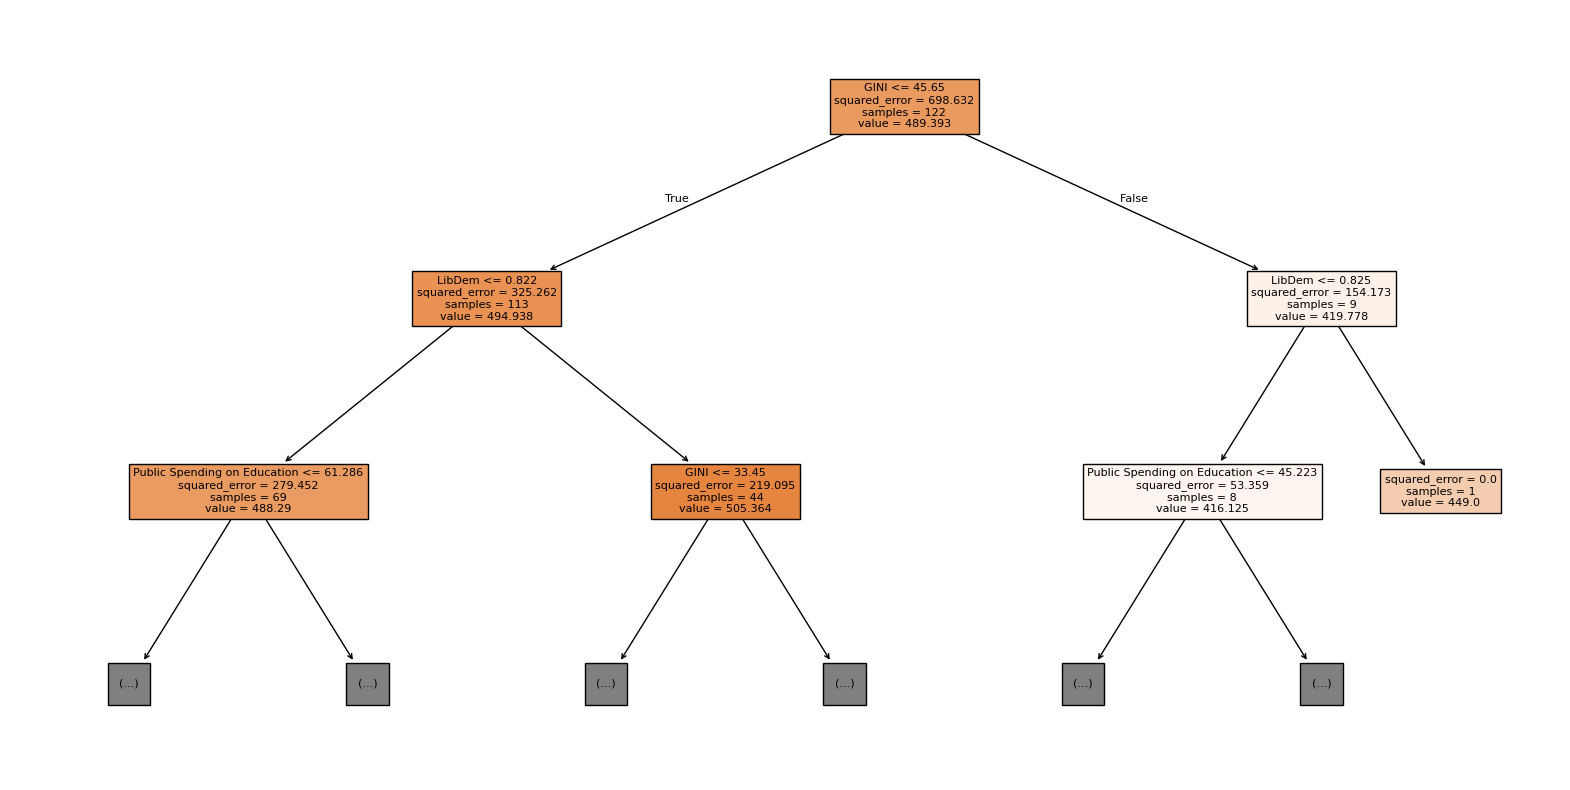

In [4]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

X = df_pca.drop(['PISA', 'PCA_scaled'], axis='columns')
y = df_pca['PISA']
dtree = DecisionTreeRegressor(max_depth = 3)
dtree.fit(X, y)

plt.figure(figsize=(20,10))
plot_tree(dtree, feature_names=X.columns, filled=True, max_depth = 2)
plt.show()

## W.8 Neural Nets (AI)

### W.8.1 Random forest (machine learning)

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
# Load the breast cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.DataFrame(data.target, columns=['target'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
rf_model = RandomForestClassifier(random_state=42)
# Fit model on training data
rf_model.fit(X_train, y_train.values.ravel())

# Make predictions on test data (unseen in training)
y_pred = rf_model.predict(X_test)
y_pred[:2]

array([1, 0])

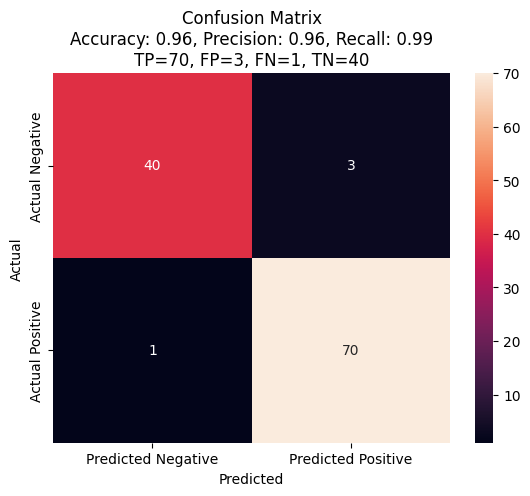

In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

# Get confusion matrix values
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Predicted Negative", "Predicted Positive"],
            yticklabels=["Actual Negative", "Actual Positive"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title(f'Confusion Matrix\nAccuracy: {accuracy:.2f}, Precision: {precision:.2f}, Recall: {recall:.2f}\nTP={tp}, FP={fp}, FN={fn}, TN={tn}')
plt.show()

### W.8.2 Neural Networks

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Assuming X and y are defined
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

import torch
# Convert to tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train.values.ravel())
y_test = torch.LongTensor(y_test.values.ravel())

import torch.nn as nn
import torch.optim as optim
# Define Neural Network
class NeuralNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(NeuralNetwork, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.layer3 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

# Initialize model, loss function, and optimizer
input_dim = X_train.shape[1]
hidden_dim = 64
output_dim = len(torch.unique(y_train))
model = NeuralNetwork(input_dim, hidden_dim, output_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

/var/folders/04/b6tjpns93xv4pyb_38bk8hx00000gn/T/ipykernel_19808/1226492065.py:15: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  y_train = torch.LongTensor(y_train.values.ravel())


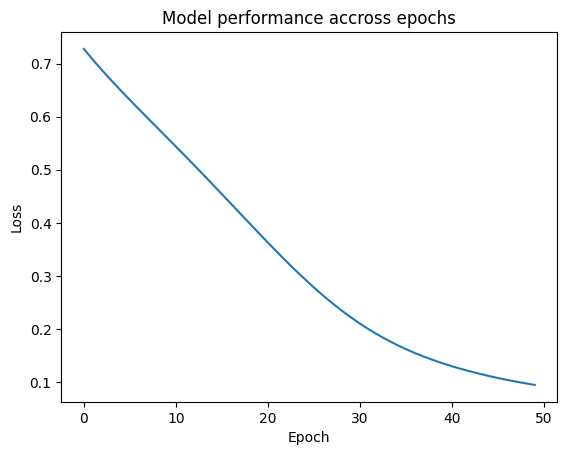

In [9]:
losses = []

# Training loop
epochs = 50
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

# Evaluation
model.eval()
with torch.no_grad():
    y_pred = model(X_test).argmax(dim=1)

import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model performance accross epochs')
plt.show()

## W.9 Natural Language Processing (NLP)

### W.9.1 Word counts

In [10]:
import pandas as pd
# IF previous 2.A doesn't work
file_name = "../../data/examples/week_7/manifesto_english_speaking.parquet"
df_all = pd.read_parquet(file_name)
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
# Count!
count_array = vectorizer.fit_transform(
                        df_all['text'] # INPUT THE TEXT COLUMN TO THE WORD COUNTER "vectorizer"
        ).toarray()

df_wordcount = pd.DataFrame(
    count_array, # Data above will become the values of the dataframe
    columns=vectorizer.get_feature_names_out(), # Words will become the column names
    index = df_all.index # Index country date comes from the df_all dataframe
)
df_wordcount.sum(axis='rows').sort_values(ascending=False).to_frame("most_common").head(10)

,most_common
the,330494
and,230602
to,209002
of,180444
in,118888
for,83003
will,81298
we,69737
that,51160
our,45675


### W.9.2 Spacy

In [11]:
from tqdm import tqdm
import spacy

# Define keywords
KEYWORDS = ["emissions", "greenhouse"]

# Load the spaCy model
nlp = spacy.load("en_core_web_sm")

# Prepare data
df_nlp = df_all.tail(10)
all_text = df_nlp['text'].to_list()

# Process text
pipe = nlp.pipe(all_text, 
                disable=['ner', 'entity_linker', 'textcat', 'textcat_multilabel'],
                # n_process=8,  
                # batch_size=10 
               )

# Initialize key sentences list
key_sentences = []

# Iterate over processed documents
for doc in tqdm(pipe):
    # Initialize list to store key sentences for the current document
    key_sentences_inonedocument = []
    
    # Iterate over sentences in the document
    for sentence in doc.sents:
        # Check if any keyword is present in the sentence
        if any(keyword.lower() in sentence.text.lower() for keyword in KEYWORDS):
            # Append the sentence to the list if a keyword is found
            key_sentences_inonedocument.append(sentence.text)
    
    # Append the list of key sentences for the current document to the main list
    key_sentences.append(key_sentences_inonedocument)

df_nlp['environment_sentences'] = key_sentences
df_nlp.head(2)

10it [00:19,  1.96s/it]


party         partyname          keys  manifesto_id  \
countryname   date                                                              
United States 2004-11-01  61320  Democratic Party  61320_200411  61320_200411   
              2004-11-01  61620  Republican Party  61620_200411  61620_200411   

                                                                       text  \
countryname   date                                                            
United States 2004-11-01  PREAMBLE As we come together to declare our vi...   
              2004-11-01  INTRODUCTION AND PREAMBLE One hundred and fift...   

                                                      environment_sentences  
countryname   date                                                           
United States 2004-11-01  [We will reduce mercury emissions, smog and ac...  
              2004-11-01  [For instance, working with Congressional Repu...

## W.10 Generative AI (Chatgpt etc)

### W.10.A Read PDFs

In [5]:
import os
from PyPDF2 import PdfReader

def read_pdf(file_path):
    result = {}
    with open(file_path, 'rb') as f:
        pdf = PdfReader(f)
        for page_num, page in enumerate(pdf.pages, start=1):
            result[f"Page {page_num}"] = page.extract_text()
    return result
path = "../../data/examples/week_7/imf_reports"
pdf_pisa_2015 = read_pdf(f"{path}/Angola_2026.pdf")

### W.10.1 RAG (Retrival augmented generation)

In [11]:
import pandas as pd # Data manipulation
import numpy as np # Numerical operations
from sklearn.metrics.pairwise import cosine_similarity # Similarity calculations
from transformers import AutoTokenizer, AutoModel # Hugging Face transformers
import torch # PyTorch for deep learning
import warnings # Warning control
warnings.filterwarnings('ignore') # Suppress warnings

def setup_rag(pdf_content,model_name='distilbert-base-uncased',max_length=512): # Initialize RAG system
    documents=list(pdf_content.values()) # Extract document text
    page_keys=list(pdf_content.keys()) # Extract page identifiers
    
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Set compute device
    tokenizer=AutoTokenizer.from_pretrained(model_name) # Load tokenizer
    model=AutoModel.from_pretrained(model_name).to(device) # Load model to device
    model.eval() # Set to evaluation mode
    
    doc_embeddings=[] # Initialize embedding storage
    
    print(f"Generating embeddings for {len(documents)} documents...") # Progress indicator
    
    with torch.no_grad(): # Disable gradient computation
        for i,doc in enumerate(documents): # Process each document
            inputs=tokenizer(doc,return_tensors='pt',truncation=True,padding=True,max_length=max_length).to(device) # Tokenize text
            
            outputs=model(**inputs) # Get model outputs
            embeddings=outputs.last_hidden_state.mean(dim=1).cpu().numpy() # Mean pool hidden states
            doc_embeddings.append(embeddings.flatten()) # Store flattened embedding
            
            if (i+1)%100==0: # Progress checkpoint
                print(f"Processed {i+1}/{len(documents)} documents") # Progress update
    
    doc_embeddings=np.array(doc_embeddings) # Convert to numpy array
    
    df=pd.DataFrame(doc_embeddings,columns=[f'dim_{i}' for i in range(doc_embeddings.shape[1])],index=[num+1 for num in range(len(documents))]) # Create DataFrame
    df.index.name='pdf_page_number' # Name the index
    df.columns.name='embedding_dimensions' # Name the columns
    
    print(f"Setup complete! Generated {doc_embeddings.shape[1]}-dimensional embeddings") # Completion message
    
    return tokenizer,model,doc_embeddings,documents,page_keys,df # Return all components

In [12]:
tokenizer, model, doc_embeddings, documents, page_keys, df = setup_rag(
    pdf_content=pdf_pisa_2015
)
df.head(4)

INFO: HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO: HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.j

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings for 86 documents...
Setup complete! Generated 768-dimensional embeddings


embedding_dimensions,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,...,dim_758,dim_759,dim_760,dim_761,dim_762,dim_763,dim_764,dim_765,dim_766,dim_767
pdf_page_number,,,,,,,,,,,,,,,,,,,,,
1,-0.342321,0.089934,0.254189,-0.036349,0.257071,-0.171710,-0.024599,0.309413,-0.181812,-0.046877,...,0.125966,0.011977,0.085885,-0.436142,-0.105987,-0.392979,-0.202196,-0.123657,0.009938,0.055366
2,-0.478667,0.053989,0.288428,0.081014,0.230164,-0.010006,-0.056180,0.310704,-0.165152,-0.115134,...,0.104357,0.004361,0.211990,-0.273822,0.020778,-0.552150,-0.100756,-0.106449,0.051239,0.008509
3,-0.417561,0.064598,0.223785,0.135326,0.194891,-0.005546,0.004815,0.194220,-0.091394,-0.110731,...,0.025950,-0.116595,0.190710,-0.179480,0.103521,-0.635499,-0.089343,-0.134512,-0.054855,-0.023121
4,-0.344413,-0.057148,0.424666,-0.042076,0.307479,-0.121910,0.057910,0.319748,-0.105259,-0.194717,...,0.131996,-0.058413,0.214757,-0.507879,0.074057,-0.794599,-0.232088,0.255150,0.209120,-0.067263


### W.10.2 Using GPU locally with ollama

In [13]:
OLLAMA_MODEL = "llama3.2:latest"

def llm_ollama(prompt, model=OLLAMA_MODEL):
    response = requests.post(
        "http://localhost:11434/api/chat",
        json={
            "model": model,
            "messages": [{"role": "user", "content": prompt}],
            "stream": False
        },
        timeout=120
    )
    response.raise_for_status()
    return response.json()["message"]["content"]

In [14]:
import requests
OLLAMA_MODEL = "llama3.2:latest"

def llm_ollama(prompt, model=OLLAMA_MODEL):
    response = requests.post(
        "http://localhost:11434/api/chat",
        json={
            "model": model,
            "messages": [{"role": "user", "content": prompt}],
            "stream": False
        },
        timeout=120
    )
    response.raise_for_status()
    return response.json()["message"]["content"]


def retrieve_documents(query, tokenizer, model, doc_embeddings, documents, page_keys, number_of_results=3):
    device = next(model.parameters()).device  # Get the device (CPU or GPU) the model is on
    # Generate query embedding
    with torch.no_grad():  # Disable gradient calculation to save memory and speed up computation
        inputs = tokenizer(
            query, 
            return_tensors='pt',  # Return PyTorch tensors
            truncation=True,  # Truncate the input if it exceeds the maximum length
            padding=True,  # Pad the input to the maximum length
            max_length=512  # Maximum length of the input
        ).to(device)  # Move the input to the same device as the model
        outputs = model(**inputs)  # Pass the input through the model
        query_embedding = outputs.last_hidden_state.mean(dim=1).cpu().numpy().flatten()  # Average the hidden states and flatten the result
    
    # Calculate cosine similarities between the query embedding and document embeddings
    similarities = cosine_similarity([query_embedding], doc_embeddings).flatten()
    # Get indices of the top results based on cosine similarity
    top_doc_indices = similarities.argsort()[-number_of_results:][::-1]
    # Build the list of retrieved documents
    retrieved = []
    for idx in top_doc_indices:
        if similarities[idx] > 0:  # Only include documents with positive similarity
            retrieved.append({
                'page': page_keys[idx],  # Page key of the document
                'content': documents[idx],  # Content of the document
                'similarity': similarities[idx]  # Similarity score
            })
    
    return pd.DataFrame(retrieved)  # Return the results as a DataFrame

def summarize_text(text, model=OLLAMA_MODEL):
    prompt = f"""Summarize the following text in 2-3 concise sentences:\n\n{text}"""
    return llm_ollama(prompt, model=model).strip()

In [15]:

# Set the maximum column width for better display of results
pd.set_option('max_colwidth', 400)
# Retrieve documents based on the query
df_results = retrieve_documents(
    query="How do economic conditions impact a country's pisa score?",  # The query to search for
    tokenizer=tokenizer,  # The tokenizer to use
    model=model,  # The model to use
    doc_embeddings=doc_embeddings,  # Precomputed document embeddings
    documents=documents,  # List of documents
    page_keys=page_keys,  # List of page keys
    number_of_results=5  # Number of top results to retrieve
)
df_results.head(3)

,page,content,similarity
0,Page 11,"ANGOLA \nINTERNATIONAL MONETARY FUND 7 inflation is expected to fall as the impact of supply -side shocks continue to recede, while weak \ndemand reinforces the disinflation trend. Temporary pressures from food and energy prices remain, \nbut the outlook points to continued easing of these pressures over the medium term (Text Figure 2) . \n7. Risks to the outlook are tilted to the dow...",0.777925
1,Page 21,"ANGOLA \nINTERNATIONAL MONETARY FUND 17 Text Figure 4. Angola: Monetary Developments, 2014 –25 \n \n \n \n \n \n24. Private credit , currently at about 6 percent of GDP, has declined steadily in the past \nten years as credit growth has not kept up with GDP growth. Real credit growth is expected to \nremain negative through 2025 before gradually recovering over the medium term. Ango...",0.773377
2,Page 9,"ANGOLA \nINTERNATIONAL MONETARY FUND 5 • Inflation has eased from its peak (31 percent in July 2024) thanks to the Banco Nacional de \nAngola ’s (BNA) tight monetary policy stance but remains elevated. The annual inflation rate \nin Angola declined to 1 5.7 percent in December 2025, marking its lowest level since \nNovember 2023 and continuing a downward trend that began in August 2024. ...",0.770593


In [16]:
# Summarize the content of the retrieved documents using Ollama
df_results['llm_summary_ollama'] = df_results['content'].apply(summarize_text)
df_results.head(3)


,page,content,similarity,llm_summary_ollama
0,Page 11,"ANGOLA \nINTERNATIONAL MONETARY FUND 7 inflation is expected to fall as the impact of supply -side shocks continue to recede, while weak \ndemand reinforces the disinflation trend. Temporary pressures from food and energy prices remain, \nbut the outlook points to continued easing of these pressures over the medium term (Text Figure 2) . \n7. Risks to the outlook are tilted to the dow...",0.777925,"Here is a summary of the text in 2-3 concise sentences:\n\nAngola's inflation is expected to fall as supply-side shocks recede and demand weakens, but risks remain tilted to the downside due to concerns over oil prices and domestic production challenges. A reversal in oil prices could lead to significant economic impacts and repricing of sovereign spreads, amplifying liquidity risks. Good gove..."
1,Page 21,"ANGOLA \nINTERNATIONAL MONETARY FUND 17 Text Figure 4. Angola: Monetary Developments, 2014 –25 \n \n \n \n \n \n24. Private credit , currently at about 6 percent of GDP, has declined steadily in the past \nten years as credit growth has not kept up with GDP growth. Real credit growth is expected to \nremain negative through 2025 before gradually recovering over the medium term. Ango...",0.773377,"Here is a 3-sentence summary of the text:\n\nAngola's private credit, currently at around 6% of GDP, has declined steadily over the past decade due to slow credit growth relative to GDP growth. The country lags behind peers in financial inclusion and access to finance for small- and medium-sized enterprises (SMEs), with low account ownership rates and weak financial infrastructure. The governm..."
2,Page 9,"ANGOLA \nINTERNATIONAL MONETARY FUND 5 • Inflation has eased from its peak (31 percent in July 2024) thanks to the Banco Nacional de \nAngola ’s (BNA) tight monetary policy stance but remains elevated. The annual inflation rate \nin Angola declined to 1 5.7 percent in December 2025, marking its lowest level since \nNovember 2023 and continuing a downward trend that began in August 2024. ...",0.770593,"Here is a summary of the text in 2-3 concise sentences:\n\nAngola's inflation rate has declined to its lowest level since November 2023, falling to 15.7% in December 2025. This decrease is largely due to the Banco Nacional de Angola's tight monetary policy stance and improved availability of goods. The country's inflation rate was previously at a peak of 31% in July 2024."


### W.10.3 Using closed source model: Claude (competitor to ChatGPT)

In [ ]:
import anthropic
import os
from dotenv import load_dotenv

load_dotenv()
client = anthropic.Anthropic(api_key=os.getenv("CLAUDE_API"))

def llm_claude(input_text, claude_model="claude-3-haiku"):
    messages = [
        {"role": "user", "content": input_text}
    ]
    chat_completion = client.messages.create(
        model=claude_model,
        max_tokens=100,
        messages=messages
    )
    return chat_completion
# Fixed function call - using the correct function name
claude_response = llm_claude(
    input_text="Tell me a fun fact about Japan.", 
    claude_model="claude-3-5-sonnet-20241022"
)
# Access the response content
claude_response.content[0].text

'Here\'s a fun fact: In Japan, there\'s an island called Ōkunoshima, also known as "Rabbit Island," which is home to hundreds of friendly wild rabbits. The island was once used for chemical weapons production during World War II, but today it\'s a popular tourist destination where visitors can feed and interact with the numerous rabbits that freely roam the island. No one knows exactly how the rabbits first came to the island, but they\'ve since multiplie'

### W.10.4 Agents
- See huggingface agent in notebook

In [ ]:
import os
from langchain_anthropic import ChatAnthropic
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper
from langchain.agents import create_react_agent, AgentExecutor
from langchain import hub
from langchain.callbacks import get_openai_callback
from dotenv import load_dotenv

load_dotenv()

def search_with_claude_tracked(query):
    """
    Enhanced arXiv search using Claude with token tracking
    """
    api_key = os.getenv("CLAUDE_API")
    
    # Initialize Claude LLM
    llm = ChatAnthropic(
        model="claude-3-5-sonnet-20241022",
        anthropic_api_key=api_key,
        temperature=0.2,
        max_tokens=1000
    )
    
    # Initialize arXiv tool
    arxiv_tool = ArxivQueryRun(
        api_wrapper=ArxivAPIWrapper(
            top_k_results=3, 
            doc_content_chars_max=800
        )
    )
    
    # Get the ReAct prompt template
    prompt = hub.pull("hwchase17/react")
    
    # Create agent
    agent = create_react_agent(llm, [arxiv_tool], prompt)
    
    # Create agent executor
    agent_executor = AgentExecutor(
        agent=agent,
        tools=[arxiv_tool],
        verbose=True,
        handle_parsing_errors=True
    )
    
    # Track tokens using callback (note: this works better with OpenAI models)
    try:
        with get_openai_callback() as cb:
            result = agent_executor.invoke({
                "input": f"Search arXiv for papers about: {query}. Provide a summary of the most relevant findings."
            })
            
            # Print token usage info
            print(f"\nToken Usage:")
            print(f"Total Tokens: {cb.total_tokens}")
            print(f"Prompt Tokens: {cb.prompt_tokens}")
            print(f"Completion Tokens: {cb.completion_tokens}")
            print(f"Total Cost (USD): ${cb.total_cost}")
            
        return result["output"]
    except Exception as e:
        return f"Error occurred: {str(e)}"

# Run the search
result = search_with_claude_tracked("quantum computing")
print("\nSearch Results:")
print("=" * 50)
print(result)



> Entering new AgentExecutor chain...
Let me search arXiv for papers about quantum computing.

Action: arxiv
Action Input: quantum computing
No good Arxiv Result was foundLet me try a more specific search query.

Action: arxiv
Action Input: "quantum computation recent advances"
No good Arxiv Result was foundI apologize, but I'm experiencing difficulty retrieving results from the arXiv tool at the moment. However, I can provide you with a general overview of quantum computing based on widely accepted knowledge:

Final Answer: 
While I wasn't able to retrieve specific recent papers from arXiv, quantum computing is a rapidly evolving field that combines quantum physics with computer science. The key aspects include:

1. Quantum Bits (Qubits): Unlike classical bits (0 or 1), qubits can exist in multiple states simultaneously due to superposition.

2. Main Applications:
- Cryptography and security
- Complex optimization problems
- Drug discovery and molecular simulation
- Financial modeli